In [2]:
from pathlib import Path
import sys
import importlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
SRC = PROJECT / "src"
OUTPUT = PROJECT / "output"

sys.path.insert(0, str(SRC))

import maps

importlib.reload(maps)

maps_data = maps.prepare_regions(DATA)

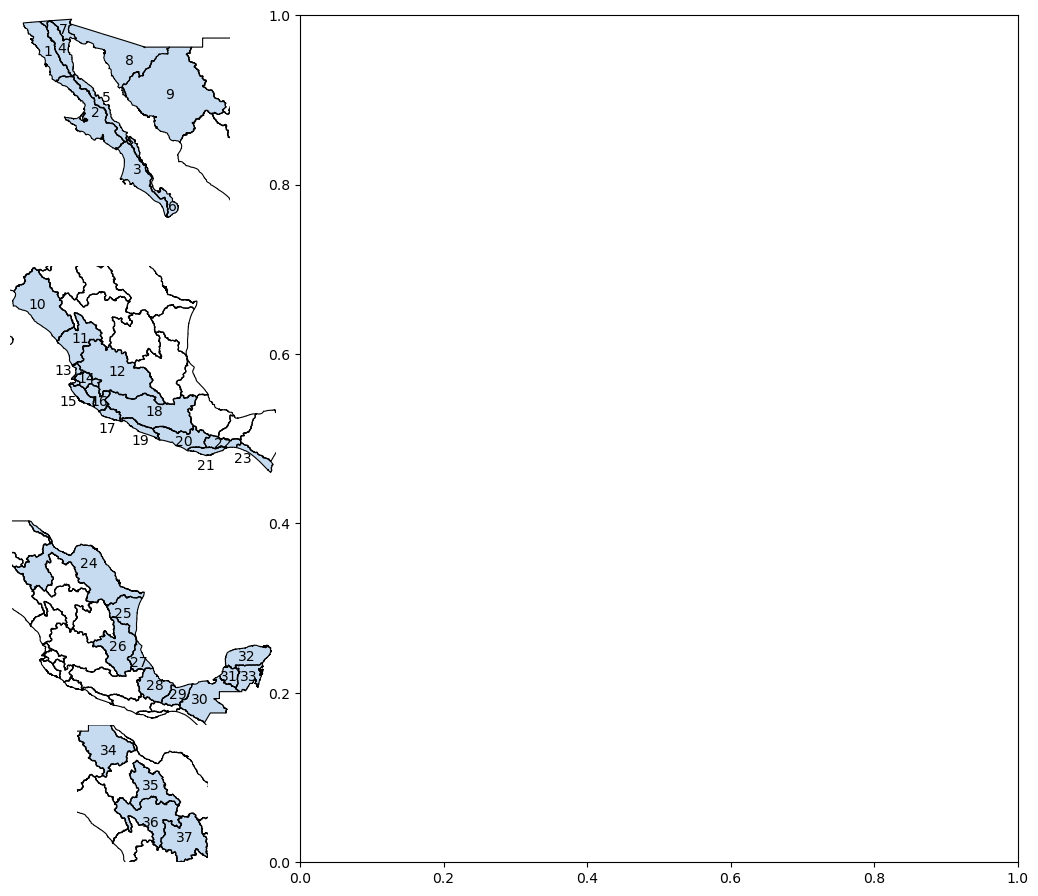

In [3]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# ------------------------------------------------------------
# Relative heights of the hydroclimatic domains
# ------------------------------------------------------------

#height_ratios = [
#    len(maps.DOMAINS["NW"]),
#    len(maps.DOMAINS["PC"]),
#    len(maps.DOMAINS["GC"]),
#    len(maps.DOMAINS["NC"]),
#]
# Relative heights used for the final figure layout.
# They are slightly adjusted from the number of Hydrological Regions
# to improve the visual balance among the four maps.
height_ratios = [9, 13, 9, 6]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(13, 11))

# Main layout: maps | heatmap
outer_gs = GridSpec(
    nrows=1,
    ncols=2,
    figure=fig,
    width_ratios=[1.0, 2.7],
    wspace=0.05,
)

# Left column (maps)
left_gs = GridSpecFromSubplotSpec(
    nrows=4,
    ncols=1,
    subplot_spec=outer_gs[0],
    height_ratios=height_ratios,
    hspace=0.0,
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax_nw = fig.add_subplot(left_gs[0])
ax_pc = fig.add_subplot(left_gs[1])
ax_gc = fig.add_subplot(left_gs[2])
ax_nc = fig.add_subplot(left_gs[3])

ax_heat = fig.add_subplot(outer_gs[1])

# ------------------------------------------------------------
# Draw maps
# ------------------------------------------------------------

maps.plot_domain(ax_nw, maps_data, "NW", mx=0.02, my=0.02)
maps.plot_domain(ax_pc, maps_data, "PC", mx=0.01, my=0.01)
maps.plot_domain(ax_gc, maps_data, "GC", mx=0.01, my=0.01)
maps.plot_domain(ax_nc, maps_data, "NC", mx=0.00, my=0.00)

# Move the NW map slightly to the left
pos = ax_nw.get_position()
ax_nw.set_position([
    pos.x0 - 0.014,   # adjust this value
    pos.y0,
    pos.width,
    pos.height
])

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = np.array([
    [230,230,230],
    [153,250,153],
    [88,250,87],
    [50,205,51],
    [35,140,35],
    [20,160,20],
    [180,210,255],
    [70,140,255],
    [0,150,255],
    [0,100,200],
    [0,60,120],
    [255,255,99],
    [255,200,1],
    [255,150,0],
    [255,100,0],
    [254,0,0],
    [176,0,0],
    [100,0,0],
    [255,0,255],
    [150,0,255],
    [140,10,80]
], dtype=float)/255

from matplotlib import cm
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------
# Precipitation classes
# ------------------------------------------------------------

levels = np.array([
    0,
    2,
    5,
    10,
    20,
    40,
    60,
    80,
    120,
    160,
    240
])

nColors = len(levels) - 1

# ------------------------------------------------------------
# Interpolated colormap (same as notebook 01)
# ------------------------------------------------------------

base_cmap = ListedColormap(cmap)

colors = base_cmap(np.linspace(0, 1, nColors))

cmap_use = ListedColormap(colors)

print(cmap_use.N)

10


In [5]:
# ==========================================================
# Heatmap data
# ==========================================================

from scipy.io import loadmat
from matplotlib.colors import ListedColormap

# Read climatology
mat = loadmat(DATA / "PPT_SMN_81_24.mat")
PPT = mat["PPT_SMN_81_24"]

# Mean climatology using only the first 44 years (indices 0–43)
M = np.mean(PPT[:, 0:44, :], axis=1)

# Keep the first 24 fortnights
M = M[:24, :]

print(M.shape)

(24, 37)


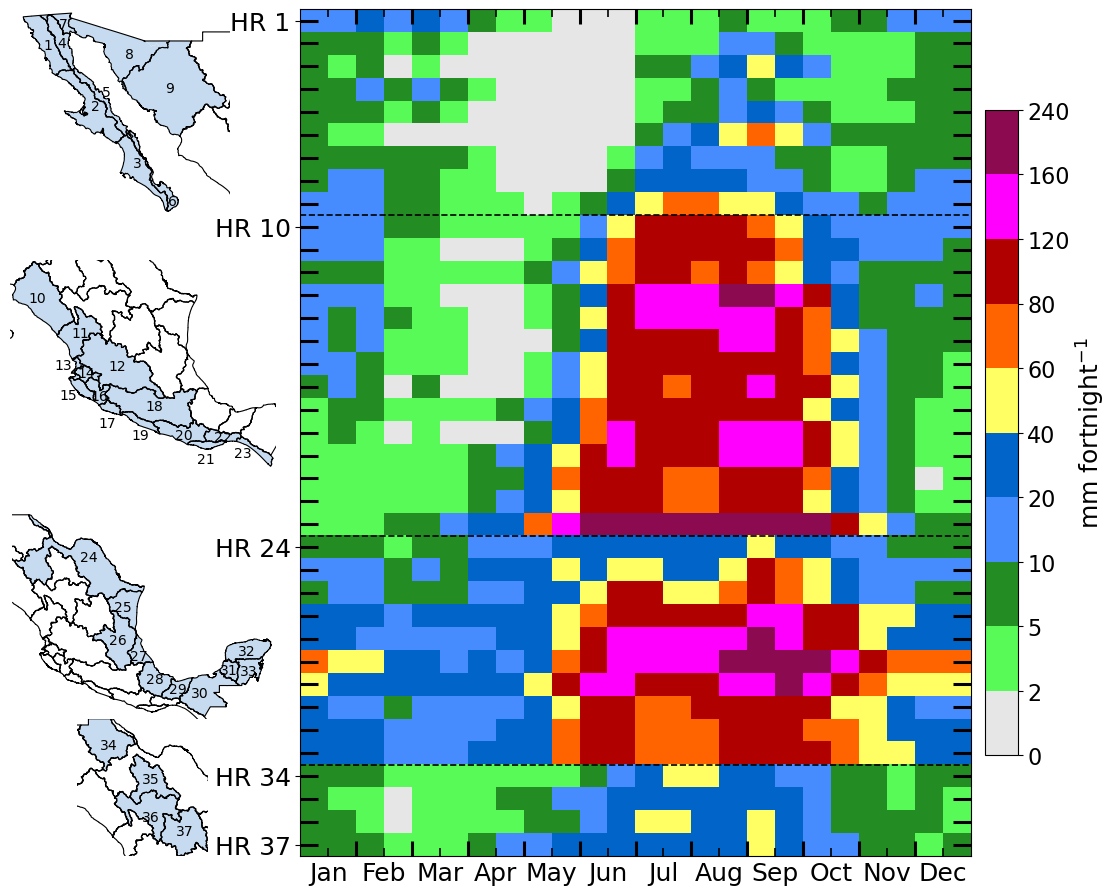

In [6]:
# ==========================================
# Primer heatmap
# ==========================================

# Un color para cada intervalo
norm = BoundaryNorm(levels, cmap_use.N, clip=True)

# Dibujar la climatología (NO la discretizada)
im = ax_heat.imshow(
    M.T,
    cmap=cmap_use,
    norm=norm,
    origin="upper",
    aspect="auto",
    interpolation="nearest"
)
ax_heat.set_ylim(36.5, -0.5)

# ==========================================
# Eje X (meses)
# ==========================================

months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# Etiquetas y ticks cortos 
ax_heat.set_xticks(np.arange(0.5, 24, 2))
ax_heat.set_xticklabels(months, fontsize=18)

ax_heat.tick_params(
    axis="x",
    which="major",
    direction="in",
    top=True,
    bottom=True,
    length=6,
    width=1.2,
)
# ==========================================
# Ticks largos (segunda quincena)
# ==========================================

ymin, ymax = ax_heat.get_ylim()

L = 0.65

for x in np.arange(1.5, 23, 2):

    # Tick superior
    ax_heat.plot(
        [x, x],
        [ymax, ymax + L],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

    # Tick inferior
    ax_heat.plot(
        [x, x],
        [ymin, ymin - L],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )
# ==========================================
# Axe Y (HR)
# ==========================================

ax_heat.set_yticks([0,9,23,33,36])

ax_heat.set_yticklabels(
    ["HR 1","HR 10","HR 24","HR 34","HR 37"],
    fontsize=18
)
# ==========================================
# Ticks 
# ==========================================

xmin, xmax = ax_heat.get_xlim()

L = 0.65

for y in np.arange(37):

    # Tick left
    ax_heat.plot(
        [xmin, xmin + L],
        [y, y],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

    # Tick right
    ax_heat.plot(
        [xmax, xmax - L],
        [y, y],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

#ax_heat.set_xlabel("Fortnights", fontsize=16)
#ax_heat.set_ylabel("Hydrological Regions", fontsize=16)
# ==========================================
# Dividers
# ==========================================

for y in [8.5, 22.5, 32.5]:
    ax_heat.axhline(
        y,
        color="black",
        linestyle="--",
        linewidth=1.2
    )
# ==========================================
# Colorbar
# ==========================================

cbar = fig.colorbar(
    im,
    ax=ax_heat,
    ticks=levels,
    spacing="uniform",
    fraction=0.045,
    pad=0.02,
)
cbar.set_label(
    r"mm fortnight$^{-1}$",
    fontsize=18
)

cbar.ax.tick_params(labelsize=16)

fig


In [7]:
# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.savefig(
    OUTPUT / "Figure_02_climatology.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    OUTPUT / "Figure_02_climatology.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()